In [15]:

# CELL 1 - Install & imports

!pip install fastf1 xgboost scikit-learn pandas numpy matplotlib seaborn requests -q

import fastf1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import requests, warnings, os, time, json
from datetime import datetime

from xgboost import XGBClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline

warnings.filterwarnings('ignore')
np.random.seed(42)

os.makedirs('/content/f1_cache', exist_ok=True)
fastf1.Cache.enable_cache('/content/f1_cache')

TEAM_COLORS = {
    'mercedes':'#00d2be','red_bull':'#3671c6','ferrari':'#e8002d',
    'mclaren':'#ff8000','rb':'#6692ff','racing_bulls':'#6692ff',
    'sauber':'#00e701','haas':'#b6babd','alpine':'#0090ff',
    'williams':'#64c4ff','aston_martin':'#358c75','cadillac':'#f0d45c',
}

print(f' FastF1 version: {fastf1.__version__}')
print(' All libraries loaded!')

 FastF1 version: 3.8.1
 All libraries loaded!


In [16]:
# CELL 2 - Fetch historical Suzuka race results
#           Jolpica API: 2018-2025 (all drivers per race)



BASE      = 'https://api.jolpi.ca/ergast/f1'
JPN_YEARS = [2018, 2019, 2022, 2023, 2024, 2025]  # 2020/2021 cancelled

def fetch_race_results(year, circuit):
    url = f'{BASE}/{year}/circuits/{circuit}/results.json?limit=30'
    r   = requests.get(url, timeout=20)
    r.raise_for_status()
    races = r.json()['MRData']['RaceTable']['Races']
    if not races: return None
    rows = []
    for res in races[0]['Results']:
        rows.append({
            'year':        year,
            'driver_id':   res['Driver']['driverId'],
            'driver_name': res['Driver']['givenName'] + ' ' + res['Driver']['familyName'],
            'constructor': res['Constructor']['constructorId'],
            'grid':        int(res.get('grid', 0)),
            'finish_pos':  int(res['position']),
            'status':      res['status'],
            'points':      float(res['points']),
        })
    df = pd.DataFrame(rows)
    winner = df[df['finish_pos']==1]['driver_name'].values[0]
    print(f'  {year}: {len(df)} drivers | Winner: {winner}')
    return df

def fetch_quali_results(year, circuit):
    url = f'{BASE}/{year}/circuits/{circuit}/qualifying.json?limit=30'
    r   = requests.get(url, timeout=20)
    r.raise_for_status()
    races = r.json()['MRData']['RaceTable']['Races']
    if not races: return None
    rows = []
    for res in races[0]['QualifyingResults']:
        rows.append({
            'year':      year,
            'driver_id': res['Driver']['driverId'],
            'quali_pos': int(res['position']),
        })
    return pd.DataFrame(rows)

print('Fetching Suzuka historical data...')
race_frames, quali_frames = [], []
for yr in JPN_YEARS:
    try:
        rf = fetch_race_results(yr, 'suzuka')
        qf = fetch_quali_results(yr, 'suzuka')
        if rf is not None: race_frames.append(rf)
        if qf is not None: quali_frames.append(qf)
    except Exception as e:
        print(f'  {yr}: {e}')
    time.sleep(0.4)

hist_races = pd.concat(race_frames,  ignore_index=True)
hist_quali = pd.concat(quali_frames, ignore_index=True)

# Sanity check
print(f'\n Total rows: {len(hist_races)} | Win rate: {(hist_races["finish_pos"]==1).mean():.3f} (should be ~0.05)')
print('Winners per year:')
print(hist_races[hist_races['finish_pos']==1][['year','driver_name']].to_string(index=False))

Fetching Suzuka historical data...
  2018: 20 drivers | Winner: Lewis Hamilton
  2019: 20 drivers | Winner: Valtteri Bottas
  2022: 20 drivers | Winner: Max Verstappen
  2023: 20 drivers | Winner: Max Verstappen
  2024: 20 drivers | Winner: Max Verstappen
  2025: 20 drivers | Winner: Max Verstappen

 Total rows: 120 | Win rate: 0.050 (should be ~0.05)
Winners per year:
 year     driver_name
 2018  Lewis Hamilton
 2019 Valtteri Bottas
 2022  Max Verstappen
 2023  Max Verstappen
 2024  Max Verstappen
 2025  Max Verstappen


In [30]:
def fetch_season_results(year):
    """Fetch ALL race results for a full season using pagination."""
    all_rows = []
    offset   = 0
    limit    = 100

    while True:
        url = f'{BASE}/{year}/results.json?limit={limit}&offset={offset}'
        r   = requests.get(url, timeout=30)
        r.raise_for_status()
        data  = r.json()
        races = data['MRData']['RaceTable']['Races']
        total = int(data['MRData']['total'])

        if not races:
            break

        for race in races:
            rnd = int(race['round'])
            for res in race['Results']:
                all_rows.append({
                    'year':        year,
                    'round':       rnd,
                    'driver_id':   res['Driver']['driverId'],
                    'constructor': res['Constructor']['constructorId'],
                    'grid':        int(res.get('grid', 0)),
                    'finish_pos':  int(res['position']),
                    'points':      float(res['points']),
                    'status':      res['status'],
                })

        offset += limit
        if offset >= total:
            break
        time.sleep(0.2)

    return pd.DataFrame(all_rows)

print('Fetching full seasons 2022-2025 (with pagination)...')
season_frames = []
for yr in [2022, 2023, 2024, 2025]:
    try:
        sf = fetch_season_results(yr)
        season_frames.append(sf)
        print(f'   {yr}: {len(sf)} rows  ← should be ~400-480')
    except Exception as e:
        print(f'   {yr}: {e}')
    time.sleep(0.5)

all_seasons = pd.concat(season_frames, ignore_index=True)
print(f'\n Total: {len(all_seasons)} rows  ← should be ~1600-1900')





Fetching full seasons 2022-2025 (with pagination)...
   2022: 440 rows  ← should be ~400-480
   2023: 440 rows  ← should be ~400-480
   2024: 479 rows  ← should be ~400-480
   2025: 479 rows  ← should be ~400-480

 Total: 1838 rows  ← should be ~1600-1900


In [31]:
# CELL 4 - FastF1: Pull Suzuka tyre deg, pit stop
#           efficiency & race pace delta
#           Using 2024 Japanese GP (most recent)
print('Loading 2024 Japanese GP via FastF1...')
print('(First run downloads ~80MB — takes 2-3 mins)')

session_r = fastf1.get_session(2024, 'Japan', 'R')
session_r.load(telemetry=False, weather=True, messages=False)

session_q = fastf1.get_session(2024, 'Japan', 'Q')
session_q.load(telemetry=False, weather=False, messages=False)

laps_r = session_r.laps.copy()
laps_q = session_q.laps.copy()

# Tyre degradation per compound
# Compute avg lap time per lap number per compound
# Deg rate = slope of lap time increase over stint

laps_r['LapTimeSeconds'] = laps_r['LapTime'].dt.total_seconds()
quick = laps_r.pick_quicklaps(threshold=1.07).copy()
quick = quick[quick['LapNumber'] > 3]  # exclude outlap

deg_rates = {}
for compound in ['SOFT','MEDIUM','HARD']:
    comp_laps = quick[quick['Compound'] == compound].copy()
    if len(comp_laps) < 5:
        deg_rates[compound] = 0.05
        continue
    # Linear fit: lap time ~ a + b * stint_lap → b = deg rate
    comp_laps['StintLap'] = comp_laps.groupby(['Driver','Stint']).cumcount() + 1
    from numpy.polynomial import polynomial as P
    coeffs = np.polyfit(comp_laps['StintLap'], comp_laps['LapTimeSeconds'], 1)
    deg_rates[compound] = round(float(coeffs[0]), 4)  # seconds per lap

print(f'\n Suzuka tyre deg rates (sec/lap):')
for c, r in deg_rates.items():
    print(f'   {c}: +{r:.4f}s per lap')
#  Pit stop efficiency per constructor
pit_data = session_r.laps[session_r.laps['PitOutTime'].notna()].copy()
pit_data['pit_duration'] = (pit_data['PitOutTime'] - pit_data['PitInTime']).dt.total_seconds()
pit_data = pit_data[pit_data['pit_duration'].between(15, 35)]
pit_data['Team'] = pit_data['Team'].str.lower().str.replace(' ', '_')

pit_efficiency = pit_data.groupby('Team')['pit_duration'].mean().reset_index()
pit_efficiency.columns = ['team_f1', 'avg_pit_sec']
# Normalise: lower pit time = higher efficiency score
pit_efficiency['pit_efficiency_score'] = 1 - (
    (pit_efficiency['avg_pit_sec'] - pit_efficiency['avg_pit_sec'].min()) /
    (pit_efficiency['avg_pit_sec'].max() - pit_efficiency['avg_pit_sec'].min() + 1e-9)
)
print(f'\n Pit stop efficiency (higher = faster stops):')
print(pit_efficiency[['team_f1','avg_pit_sec','pit_efficiency_score']]
      .sort_values('pit_efficiency_score', ascending=False).to_string(index=False))

#  Race pace delta (race pace minus quali pace)
# Drivers who maintain quali pace in race = strong race setup
q_times = laps_q.pick_quicklaps().groupby('Driver')['LapTime'].min().dt.total_seconds()
r_times = quick.groupby('Driver')['LapTimeSeconds'].median()
pace_delta = (r_times - q_times).reset_index()
pace_delta.columns = ['Driver','race_pace_delta']
# Lower delta = driver/car maintains pace well
pace_delta['race_pace_score'] = 1 / (1 + np.exp(0.1 * (pace_delta['race_pace_delta'] - pace_delta['race_pace_delta'].median())))
print(f'\n Race pace delta (top drivers):')
print(pace_delta.sort_values('race_pace_delta').head(8).to_string(index=False))

print('\n FastF1 data extracted!')

core           INFO 	Loading data for Japanese Grand Prix - Race [v3.8.1]
INFO:fastf1.fastf1.core:Loading data for Japanese Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
INFO:fastf1.fastf1.req:Using cached data for session_info
req            INFO 	Using cached data for driver_info
INFO:fastf1.fastf1.req:Using cached data for driver_info


Loading 2024 Japanese GP via FastF1...
(First run downloads ~80MB — takes 2-3 mins)


req            INFO 	Using cached data for session_status_data
INFO:fastf1.fastf1.req:Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
INFO:fastf1.fastf1.req:Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
INFO:fastf1.fastf1.req:Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
INFO:fastf1.fastf1.req:Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
INFO:fastf1.fastf1.req:Using cached data for timing_app_data
core           INFO 	Processing timing data...
INFO:fastf1.fastf1.core:Processing timing data...
req            INFO 	Using cached data for weather_data
INFO:fastf1.fastf1.req:Using cached data for weather_data
core           INFO 	Finished loading data for 20 drivers: ['1', '11', '55', '16', '4', '14', '63', '81', '44', '22', '27', '18', '20', '77', '31', '10', '2', '24', '3', '23']
I


 Suzuka tyre deg rates (sec/lap):
   SOFT: +-0.0656s per lap
   MEDIUM: +0.0347s per lap
   HARD: +0.0020s per lap

 Pit stop efficiency (higher = faster stops):
Empty DataFrame
Columns: [team_f1, avg_pit_sec, pit_efficiency_score]
Index: []

 Race pace delta (top drivers):
Driver  race_pace_delta  race_pace_score
   SAR           7.5760         0.515508
   STR           7.6570         0.513484
   RUS           7.6935         0.512572
   LEC           7.7330         0.511585
   HAM           7.8455         0.508774
   NOR           7.8685         0.508199
   OCO           7.9640         0.505812
   TSU           8.0850         0.502787

 FastF1 data extracted!


In [32]:

# CELL 5 — Live weather forecast via Open-Meteo
#           Suzuka coordinates: 34.8431°N, 136.5419°E
#           Race Sunday March 30, 2026 ~14:00 JST


def fetch_suzuka_weather():
    """
    Fetch hourly forecast for Suzuka on race day.
    Returns weather impact score (0=dry/fast, 1=wet/chaotic)
    """
    url = (
        'https://api.open-meteo.com/v1/forecast'
        '?latitude=34.8431&longitude=136.5419'
        '&hourly=temperature_2m,precipitation_probability,precipitation,windspeed_10m,weathercode'
        '&timezone=Asia%2FTokyo'
        '&forecast_days=2'
    )
    r    = requests.get(url, timeout=15)
    r.raise_for_status()
    data = r.json()

    # Find race window: Sunday 13:00-16:00 JST
    times  = data['hourly']['time']
    precip = data['hourly']['precipitation_probability']
    rain   = data['hourly']['precipitation']
    wind   = data['hourly']['windspeed_10m']
    wcode  = data['hourly']['weathercode']

    race_hours = [i for i, t in enumerate(times) if '2026-03-30' in t and
                  any(f'T{h}:00' in t for h in ['13','14','15','16'])]

    if not race_hours:
        print('    Could not find race window in forecast, using default dry conditions')
        return {'rain_prob': 0.10, 'rain_mm': 0.0, 'wind_kmh': 10,
                'weather_impact': 0.05, 'condition': 'Assumed dry'}

    avg_rain_prob = np.mean([precip[i] for i in race_hours])
    avg_rain_mm   = np.mean([rain[i]   for i in race_hours])
    avg_wind      = np.mean([wind[i]   for i in race_hours])

    # Weather impact score: 0 = dry race, 1 = fully wet
    weather_impact = min(1.0, (avg_rain_prob/100)*0.6 + min(avg_rain_mm/5, 1)*0.4)

    condition = 'Dry' if avg_rain_prob < 20 else \
                'Possible light rain' if avg_rain_prob < 50 else \
                'Likely wet' if avg_rain_prob < 75 else 'Wet race'

    return {
        'rain_prob':      round(avg_rain_prob, 1),
        'rain_mm':        round(avg_rain_mm, 2),
        'wind_kmh':       round(avg_wind, 1),
        'weather_impact': round(weather_impact, 3),
        'condition':      condition
    }

print('  Fetching live Suzuka weather forecast...')
weather = fetch_suzuka_weather()
print(f'\n  SUZUKA RACE DAY FORECAST (March 29, 2026):')
print(f'   Condition:        {weather["condition"]}')
print(f'   Rain probability: {weather["rain_prob"]}%')
print(f'   Expected rain:    {weather["rain_mm"]}mm')
print(f'   Wind speed:       {weather["wind_kmh"]} km/h')
print(f'   Weather impact:   {weather["weather_impact"]} (0=dry, 1=wet)')

  Fetching live Suzuka weather forecast...

  SUZUKA RACE DAY FORECAST (March 29, 2026):
   Condition:        Dry
   Rain probability: 8.5%
   Expected rain:    0.0mm
   Wind speed:       8.4 km/h
   Weather impact:   0.051 (0=dry, 1=wet)


In [33]:

# CELL 6 — 2026 season form signals
#           AUS + CHN results → update constructor
#           pace weights with REAL race data


# Real 2026 race results (AUS R1, CHN R2)
results_2026 = [
    # race, driver_id, finish_pos, points, status
    # AUSTRALIA
    ('aus', 'russell',        1, 25, 'Finished'),
    ('aus', 'antonelli',      2, 18, 'Finished'),
    ('aus', 'leclerc',        3, 15, 'Finished'),
    ('aus', 'hamilton',       4, 12, 'Finished'),
    ('aus', 'norris',         5, 10, 'Finished'),
    ('aus', 'max_verstappen', 6,  8, 'Finished'),
    ('aus', 'bearman',        7,  6, 'Finished'),
    ('aus', 'lindblad',       8,  4, 'Finished'),
    ('aus', 'bortoleto',      9,  2, 'Finished'),
    ('aus', 'gasly',         10,  1, 'Finished'),
    ('aus', 'piastri',        0,  0, 'DNS'),
    ('aus', 'hulkenberg',     0,  0, 'DNS'),
    ('aus', 'hadjar',         0,  0, 'DNF'),
    ('aus', 'alonso',         0,  0, 'DNF'),
    ('aus', 'bottas',         0,  0, 'DNF'),
    # CHINA
    ('chn', 'antonelli',      1, 25, 'Finished'),
    ('chn', 'russell',        2, 18, 'Finished'),
    ('chn', 'hamilton',       3, 15, 'Finished'),
    ('chn', 'leclerc',        4, 12, 'Finished'),
    ('chn', 'bearman',        5, 10, 'Finished'),
    ('chn', 'gasly',          6,  8, 'Finished'),
    ('chn', 'lawson',         7,  6, 'Finished'),
    ('chn', 'hadjar',         8,  4, 'Finished'),
    ('chn', 'sainz',          9,  2, 'Finished'),
    ('chn', 'colapinto',     10,  1, 'Finished'),
    ('chn', 'max_verstappen', 0,  0, 'DNF'),
    ('chn', 'alonso',         0,  0, 'DNF'),
    ('chn', 'stroll',         0,  0, 'DNF'),
    ('chn', 'norris',         0,  0, 'DNS'),
    ('chn', 'piastri',        0,  0, 'DNS'),
    ('chn', 'bortoleto',      0,  0, 'DNS'),
    ('chn', 'albon',          0,  0, 'DNS'),
]

df_2026_season = pd.DataFrame(results_2026,
    columns=['race','driver_id','finish_pos','points','status'])

# Driver 2026 form
driver_2026 = df_2026_season[df_2026_season['status'].isin(['Finished'])]\
    .groupby('driver_id').agg(
        s26_points   = ('points',     'sum'),
        s26_wins     = ('finish_pos', lambda x: (x==1).sum()),
        s26_podiums  = ('finish_pos', lambda x: (x<=3).sum()),
        s26_avg_pos  = ('finish_pos', 'mean'),
        s26_races    = ('race',       'count'),
    ).reset_index()
driver_2026['s26_pts_per_race'] = driver_2026['s26_points'] / driver_2026['s26_races']

# Constructor 2026 reliability (DNF/DNS rate)
constructor_map = {
    'russell':'mercedes','antonelli':'mercedes',
    'leclerc':'ferrari','hamilton':'ferrari',
    'norris':'mclaren','piastri':'mclaren',
    'max_verstappen':'red_bull','hadjar':'red_bull',
    'lawson':'rb','lindblad':'rb',
    'bortoleto':'sauber','hulkenberg':'sauber',
    'bearman':'haas','ocon':'haas',
    'gasly':'alpine','colapinto':'alpine',
    'sainz':'williams','albon':'williams',
    'alonso':'aston_martin','stroll':'aston_martin',
    'perez':'cadillac','bottas':'cadillac',
}
df_2026_season['constructor'] = df_2026_season['driver_id'].map(constructor_map)

con_reliability_2026 = df_2026_season.groupby('constructor').agg(
    total_entries   = ('driver_id', 'count'),
    dnf_dns_count   = ('status',    lambda x: (x.isin(['DNF','DNS'])).sum()),
).reset_index()
con_reliability_2026['dnf_dns_rate_2026'] = (
    con_reliability_2026['dnf_dns_count'] / con_reliability_2026['total_entries']
)

print('2026 Driver standings so far:')
print(driver_2026.sort_values('s26_points', ascending=False)
      [['driver_id','s26_points','s26_wins','s26_podiums']].to_string(index=False))
print('\n2026 Constructor reliability:')
print(con_reliability_2026[['constructor','dnf_dns_rate_2026']]
      .sort_values('dnf_dns_rate_2026').to_string(index=False))

2026 Driver standings so far:
     driver_id  s26_points  s26_wins  s26_podiums
     antonelli          43         1            2
       russell          43         1            2
      hamilton          27         0            1
       leclerc          27         0            1
       bearman          16         0            0
        norris          10         0            0
         gasly           9         0            0
max_verstappen           8         0            0
        lawson           6         0            0
        hadjar           4         0            0
      lindblad           4         0            0
     bortoleto           2         0            0
         sainz           2         0            0
     colapinto           1         0            0

2026 Constructor reliability:
 constructor  dnf_dns_rate_2026
      alpine           0.000000
     ferrari           0.000000
    mercedes           0.000000
        haas           0.000000
          rb           0.0000

In [34]:

# CELL 7 — DNF Simulation Module
#           Per-driver + per-constructor +
#           2026 new-regs reliability penalty


# Historical DNF rates from full season data
recent_seasons = all_seasons[all_seasons['year'] >= 2023].copy()
driver_dnf_hist = recent_seasons.groupby('driver_id').agg(
    total_races = ('round', 'count'),
    dnf_count   = ('status', lambda x: (~x.str.startswith('Finished') & ~x.str.contains('Lap')).sum())
).reset_index()
driver_dnf_hist['hist_dnf_rate'] = driver_dnf_hist['dnf_count'] / driver_dnf_hist['total_races'].clip(lower=1)

con_dnf_hist = recent_seasons.groupby('constructor').agg(
    total_entries = ('round', 'count'),
    dnf_count     = ('status', lambda x: (~x.str.startswith('Finished') & ~x.str.contains('Lap')).sum())
).reset_index()
con_dnf_hist['hist_con_dnf_rate'] = con_dnf_hist['dnf_count'] / con_dnf_hist['total_entries'].clip(lower=1)

# 2026 new-regs penalty — scaled by how many DNS/DNFs each constructor had
# McLaren = highest penalty (4 DNS in 2 races!), Aston Martin high too
new_regs_penalty = {
    'mercedes':    0.03,  # reliable so far
    'ferrari':     0.04,
    'mclaren':     0.18,  # 4 DNS in 2 races — serious concern
    'red_bull':    0.12,  # Verstappen DNF + Hadjar DNF
    'rb':          0.05,
    'sauber':      0.08,  # Bortoleto DNS AUS
    'haas':        0.04,
    'alpine':      0.05,
    'williams':    0.07,  # Albon DNS CHN
    'aston_martin':0.15,  # Alonso DNF AUS+CHN, Stroll DNF CHN
    'cadillac':    0.09,  # Bottas DNF AUS
}

def compute_dnf_probability(driver_id, constructor):
    """
    DNF probability =
      historical driver DNF rate * 0.40
    + historical constructor DNF rate * 0.35
    + 2026 new-regs penalty * 0.25
    """
    hist_d = driver_dnf_hist[driver_dnf_hist['driver_id']==driver_id]['hist_dnf_rate']
    d_rate = float(hist_d.values[0]) if len(hist_d) else 0.10

    hist_c = con_dnf_hist[con_dnf_hist['constructor']==constructor]['hist_con_dnf_rate']
    c_rate = float(hist_c.values[0]) if len(hist_c) else 0.10

    nr_pen = new_regs_penalty.get(constructor, 0.08)

    return round(d_rate*0.40 + c_rate*0.35 + nr_pen*0.25, 4)

# Test it
test_cases = [
    ('antonelli',      'mercedes'),
    ('max_verstappen', 'red_bull'),
    ('norris',         'mclaren'),
    ('alonso',         'aston_martin'),
]
print('DNF probability per driver per race:')
for d, c in test_cases:
    prob = compute_dnf_probability(d, c)
    print(f'  {d:<20} ({c:<15}) → {prob:.1%}')

DNF probability per driver per race:
  antonelli            (mercedes       ) → 11.2%
  max_verstappen       (red_bull       ) → 6.9%
  norris               (mclaren        ) → 9.0%
  alonso               (aston_martin   ) → 13.1%


In [35]:

# CELL 8 — Compute all historical stats


#  Suzuka-specific driver stats
suzuka_stats = hist_races.groupby('driver_id').agg(
    suz_races    = ('year',       'count'),
    suz_wins     = ('finish_pos', lambda x: (x==1).sum()),
    suz_podiums  = ('finish_pos', lambda x: (x<=3).sum()),
    suz_avg_pos  = ('finish_pos', 'mean'),
    suz_points   = ('points',     'sum'),
    suz_dnf_rate = ('status',     lambda x: (~x.str.startswith('Finished')
                                             & ~x.str.contains('Lap')).mean()),
).reset_index()
suzuka_stats['suz_win_rate']    = suzuka_stats['suz_wins']    / suzuka_stats['suz_races']
suzuka_stats['suz_podium_rate'] = suzuka_stats['suz_podiums'] / suzuka_stats['suz_races']

#  Recent driver form (2024-2025)
recent = all_seasons[all_seasons['year'] >= 2024]
driver_form = recent.groupby('driver_id').agg(
    recent_wins        = ('finish_pos', lambda x: (x==1).sum()),
    recent_podiums     = ('finish_pos', lambda x: (x<=3).sum()),
    recent_points      = ('points',     'sum'),
    recent_races       = ('round',      'count'),
    recent_avg_pos     = ('finish_pos', 'mean'),
    recent_dnf_rate    = ('status',     lambda x: (~x.str.startswith('Finished')
                                                   & ~x.str.contains('Lap')).mean()),
).reset_index()
driver_form['recent_win_rate']     = driver_form['recent_wins'] / driver_form['recent_races'].clip(lower=1)
driver_form['recent_pts_per_race'] = driver_form['recent_points'] / driver_form['recent_races'].clip(lower=1)

#  Constructor form (2025)
con_form_2025 = all_seasons[all_seasons['year']==2025].groupby('constructor').agg(
    con_pts   = ('points', 'sum'),
    con_races = ('round',  'count'),
).reset_index()
con_form_2025['con_pts_per_race'] = con_form_2025['con_pts'] / con_form_2025['con_races'].clip(lower=1)

print('Suzuka driver stats (top 10 by podiums):')
print(suzuka_stats[['driver_id','suz_races','suz_wins','suz_podiums','suz_win_rate']]
      .sort_values('suz_podiums', ascending=False).head(10).to_string(index=False))

Suzuka driver stats (top 10 by podiums):
     driver_id  suz_races  suz_wins  suz_podiums  suz_win_rate
max_verstappen          6         4            5      0.666667
        bottas          5         1            2      0.200000
        norris          5         0            2      0.000000
         perez          5         0            2      0.000000
      hamilton          6         1            2      0.166667
       piastri          3         0            2      0.000000
       leclerc          6         0            1      0.000000
         sainz          6         0            1      0.000000
        vettel          3         0            1      0.000000
     bortoleto          1         0            0      0.000000


In [36]:

# CELL 9 — Build 2026 Japanese GP grid
#           with ALL features


# Real 2026 qualifying times (March 29, 2026)
# Gaps computed relative to pole (Antonelli 1:28.778)
POLE_TIME = 88.778  # seconds

grid_2026 = [
    # driver_id, name, constructor, grid_pos, quali_time_sec
    ('antonelli',      'Kimi Antonelli',    'mercedes',     1,  88.778),
    ('russell',        'George Russell',    'mercedes',     2,  89.076),
    ('piastri',        'Oscar Piastri',     'mclaren',      3,  89.132),
    ('leclerc',        'Charles Leclerc',   'ferrari',      4,  89.405),
    ('norris',         'Lando Norris',      'mclaren',      5,  89.409),
    ('hamilton',       'Lewis Hamilton',    'ferrari',      6,  89.567),
    ('gasly',          'Pierre Gasly',      'alpine',       7,  89.691),
    ('hadjar',         'Isack Hadjar',      'red_bull',     8,  89.978),
    ('bortoleto',      'Gabriel Bortoleto', 'sauber',       9,  90.274),
    ('lindblad',       'Arvid Lindblad',    'rb',          10,  90.319),
    ('max_verstappen', 'Max Verstappen',    'red_bull',    11,  90.262),
    ('ocon',           'Esteban Ocon',      'haas',        12,  90.309),
    ('hulkenberg',     'Nico Hulkenberg',   'sauber',      13,  90.387),
    ('lawson',         'Liam Lawson',       'rb',          14,  90.495),
    ('colapinto',      'Franco Colapinto',  'alpine',      15,  90.627),
    ('sainz',          'Carlos Sainz',      'williams',    16,  91.033),
    ('albon',          'Alexander Albon',   'williams',    17,  91.088),
    ('bearman',        'Oliver Bearman',    'haas',        18,  91.090),
    ('perez',          'Sergio Perez',      'cadillac',    19,  92.206),
    ('bottas',         'Valtteri Bottas',   'cadillac',    20,  92.330),
    ('alonso',         'Fernando Alonso',   'aston_martin',21,  92.646),
    ('stroll',         'Lance Stroll',      'aston_martin',22,  93.500),
]

df = pd.DataFrame(grid_2026, columns=[
    'driver_id','driver_name','constructor','grid_pos','quali_time_sec'
])

#  Grid & quali features
# SUZUKA: grid_advantage weighted MORE (low overtaking)
# Using steeper decay (-0.20 vs -0.15 for other tracks)
df['grid_advantage']  = np.exp(-0.20 * (df['grid_pos'] - 1))
df['quali_advantage'] = np.exp(-0.20 * (df['grid_pos'] - 1))

# Gap to pole in seconds (real 2026 data)
df['gap_to_pole']     = df['quali_time_sec'] - POLE_TIME
df['gap_to_pole_score'] = np.exp(-0.5 * df['gap_to_pole'])  # exponential decay

#  Merge historical Suzuka stats
df = df.merge(suzuka_stats[['driver_id','suz_win_rate','suz_podium_rate',
                             'suz_avg_pos','suz_dnf_rate']],
              on='driver_id', how='left')

#  Merge recent form
df = df.merge(driver_form[['driver_id','recent_win_rate','recent_pts_per_race',
                             'recent_avg_pos','recent_dnf_rate']],
              on='driver_id', how='left')

# Merge 2026 season form
df = df.merge(driver_2026[['driver_id','s26_pts_per_race','s26_wins']],
              on='driver_id', how='left')

#  Constructor pace: 2025 base + 2026 race evidence
# Updated after AUS + CHN: Mercedes clearly #1,
# Ferrari #2, McLaren fast but unreliable
con_pace_2026 = {
    'mercedes':    1.45,  # Won 3/4 driver spots in 2 races
    'ferrari':     1.10,  # Consistent P3-P4
    'mclaren':     1.05,  # Fast but 4 DNS — pace there, reliability isn't
    'red_bull':    0.75,  # Verstappen DNF CHN, Hadjar DNF AUS
    'rb':          0.65,  # Lawson P7 CHN — decent
    'haas':        0.60,  # Bearman P5 CHN, P7 AUS — genuinely good
    'alpine':      0.55,  # Gasly P6 CHN
    'sauber':      0.45,
    'williams':    0.40,
    'aston_martin':0.25,  # Terrible reliability, no points
    'cadillac':    0.20,
}
df = df.merge(con_form_2025[['constructor','con_pts_per_race']], on='constructor', how='left')
df['con_pace_2026']   = df['constructor'].map(con_pace_2026).fillna(0.30)

#  Pit stop efficiency
# Map FastF1 team names to constructor IDs
pit_name_map = {
    'mercedes':'mercedes','red_bull_racing':'red_bull',
    'ferrari':'ferrari','mclaren':'mclaren',
    'rb':'rb','kick_sauber':'sauber',
    'haas_f1_team':'haas','alpine':'alpine',
    'williams':'williams','aston_martin':'aston_martin',
}
pit_efficiency['constructor'] = pit_efficiency['team_f1'].map(pit_name_map)
df = df.merge(pit_efficiency[['constructor','pit_efficiency_score']],
              on='constructor', how='left')

#  Tyre deg rate (track average, per compound)
# Assign based on likely race strategy at Suzuka
# 1-stop: MEDIUM → HARD typically
df['tyre_deg_rate'] = (deg_rates.get('MEDIUM', 0.05) + deg_rates.get('HARD', 0.03)) / 2

#  Weather impact
df['weather_impact'] = weather['weather_impact']
# Wet weather bonus: Hamilton/Alonso/Verstappen historically strong in rain
wet_bonus_drivers = {'hamilton':0.15,'max_verstappen':0.12,'alonso':0.10,'norris':0.08}
df['wet_bonus'] = df['driver_id'].map(wet_bonus_drivers).fillna(0)
df['wet_bonus'] = df['wet_bonus'] * df['weather_impact']  # only matters if wet

# Track type normalisation (Suzuka)
# High downforce, technical, low overtaking
# → quali position matters more → boost grid_advantage
# → team strategy matters less → reduce pit_efficiency weight
# → power unit sensitive (long straights S1+S2)
# This is baked into the steeper -0.20 grid decay above
# + explicit suzuka_track_factor per team
suzuka_track_factor = {
    'mercedes':    1.10,  # Top speed advantage (329 km/h in quali)
    'mclaren':     1.05,  # 324 km/h, strong aero
    'ferrari':     1.00,  # 320 km/h, slight aero issue flagged
    'red_bull':    0.95,
    'rb':          0.90,
    'haas':        0.88,
    'alpine':      0.87,
    'sauber':      0.85,
    'williams':    0.83,
    'aston_martin':0.75,
    'cadillac':    0.70,
}
df['suzuka_track_factor'] = df['constructor'].map(suzuka_track_factor).fillna(0.80)

#  DNF probability for each driver
df['dnf_prob'] = df.apply(
    lambda row: compute_dnf_probability(row['driver_id'], row['constructor']), axis=1
)

#  Fill NaNs
fill_zero = ['suz_win_rate','suz_podium_rate','suz_dnf_rate',
             'recent_win_rate','recent_pts_per_race','recent_dnf_rate',
             'con_pts_per_race','pit_efficiency_score','s26_pts_per_race','s26_wins']
for col in fill_zero:
    if col in df.columns: df[col] = df[col].fillna(0)
df['suz_avg_pos']    = df['suz_avg_pos'].fillna(14)
df['recent_avg_pos'] = df['recent_avg_pos'].fillna(14)

print(df[['driver_name','grid_pos','gap_to_pole','dnf_prob','con_pace_2026',
          'suzuka_track_factor','weather_impact']].to_string(index=False))

      driver_name  grid_pos  gap_to_pole  dnf_prob  con_pace_2026  suzuka_track_factor  weather_impact
   Kimi Antonelli         1        0.000    0.1117           1.45                 1.10           0.051
   George Russell         2        0.298    0.0850           1.45                 1.10           0.051
    Oscar Piastri         3        0.354    0.0961           1.05                 1.05           0.051
  Charles Leclerc         4        0.627    0.1064           1.10                 1.00           0.051
     Lando Norris         5        0.631    0.0904           1.05                 1.05           0.051
   Lewis Hamilton         6        0.789    0.0950           1.10                 1.00           0.051
     Pierre Gasly         7        0.913    0.1246           0.55                 0.87           0.051
     Isack Hadjar         8        1.200    0.1075           0.75                 0.95           0.051
Gabriel Bortoleto         9        1.496    0.1507           0.45        

In [38]:

# CELL 10 — Build ML training dataset & train XGBoost


# Merge historical race + quali
training = hist_races.merge(
    hist_quali[['year','driver_id','quali_pos']],
    on=['year','driver_id'], how='left'
)
training['grid_advantage']  = np.exp(-0.20 * (training['grid'].clip(lower=1) - 1))
training['quali_advantage'] = np.exp(-0.20 * (training['quali_pos'].fillna(training['grid']).clip(lower=1) - 1))
training['gap_to_pole']     = 0  # not available in historical — set to 0
training['gap_to_pole_score'] = 1.0

training = training.merge(suzuka_stats, on='driver_id', how='left')
training = training.merge(driver_form,  on='driver_id', how='left')
training = training.merge(driver_2026[['driver_id','s26_pts_per_race','s26_wins']],
                           on='driver_id', how='left')
training = training.merge(con_form_2025[['constructor','con_pts_per_race']],
                           on='constructor', how='left')

training['con_pace_2026']      = training['constructor'].map(con_pace_2026).fillna(0.30)
training['suzuka_track_factor']= training['constructor'].map(suzuka_track_factor).fillna(0.80)
training['pit_efficiency_score'] = 0.5  # not available historically
training['tyre_deg_rate']      = df['tyre_deg_rate'].mean()
training['weather_impact']     = 0.05  # assume historical races mostly dry
training['wet_bonus']          = 0.0
training['dnf_prob'] = training.apply(
    lambda row: compute_dnf_probability(row['driver_id'], row['constructor']), axis=1
)
training['won'] = (training['finish_pos'] == 1).astype(int)

fill_cols = ['suz_win_rate','suz_podium_rate','suz_dnf_rate',
             'recent_win_rate','recent_pts_per_race','recent_dnf_rate',
             'con_pts_per_race','s26_pts_per_race','s26_wins']
for col in fill_cols:
    if col in training.columns: training[col] = training[col].fillna(0)
training['suz_avg_pos']    = training['suz_avg_pos'].fillna(14)
training['recent_avg_pos'] = training['recent_avg_pos'].fillna(14)

# With only 120 Suzuka rows, use fewer features to avoid overfitting
FEATURES = [
    'grid_advantage',
    'quali_advantage',
    'gap_to_pole_score',
    'suz_win_rate',
    'suz_podium_rate',
    'suz_avg_pos',
    'recent_win_rate',
    'recent_pts_per_race',
    'con_pace_2026',
    'suzuka_track_factor',
    'dnf_prob',
    's26_pts_per_race',
]
# 12 features on 120 rows = 10:1 ratio, much more reasonable

X = training[FEATURES].values
y = training['won'].values

print(f'Training: {len(X)} rows | Win rate: {y.mean():.3f} (should be ~0.05)')

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
models = {
    'XGBoost':        XGBClassifier(n_estimators=200, max_depth=3, learning_rate=0.05,
                                    subsample=0.8, colsample_bytree=0.8,
                                    min_child_weight=2, reg_alpha=0.5, reg_lambda=1.0,
                                    eval_metric='logloss', random_state=42, verbosity=0),
    'Gradient Boost': GradientBoostingClassifier(n_estimators=200, max_depth=3,
                                                  learning_rate=0.05, random_state=42),
    'Random Forest':  RandomForestClassifier(n_estimators=200, max_depth=4, random_state=42),
    'Logistic Reg.':  Pipeline([('s', StandardScaler()),
                                 ('c', LogisticRegression(C=0.5, max_iter=1000))]),
}
print('\nCross-validation ROC-AUC (5-fold):')
print('─' * 40)
for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=cv, scoring='roc_auc')
    print(f'  {name:<20}  {scores.mean():.4f} ± {scores.std():.4f}')

best_model = models['XGBoost']
best_model.fit(X, y)
print('\n XGBoost trained!')

Training: 120 rows | Win rate: 0.050 (should be ~0.05)

Cross-validation ROC-AUC (5-fold):
────────────────────────────────────────
  XGBoost               0.8783 ± 0.1903
  Gradient Boost        0.9457 ± 0.0982
  Random Forest         0.9477 ± 0.1045
  Logistic Reg.         0.9955 ± 0.0091

 XGBoost trained!


In [39]:

# CELL 11 — XGBoost predictions + model confidence


X_2026    = df[FEATURES].values
raw_probs = best_model.predict_proba(X_2026)[:, 1]
df['win_prob']     = raw_probs / raw_probs.sum()
df['win_prob_pct'] = (df['win_prob'] * 100).round(2)

pred = df[['driver_name','constructor','grid_pos','win_prob_pct']]\
         .sort_values('win_prob_pct', ascending=False).reset_index(drop=True)

#  Model confidence score
# How spread is the distribution?
# High entropy = open race | Low entropy = dominant favourite
probs = df['win_prob'].values
entropy = -np.sum(probs * np.log(probs + 1e-9))
max_entropy = np.log(len(probs))  # uniform distribution
confidence  = 1 - (entropy / max_entropy)  # 0 = totally open, 1 = one dominant driver

top1_prob = pred.iloc[0]['win_prob_pct']
top2_prob = pred.iloc[1]['win_prob_pct']

if confidence > 0.35:
    conf_label = ' HIGH — Model is confident, clear favourite'
elif confidence > 0.20:
    conf_label = ' MEDIUM — Competitive race, 2-3 likely contenders'
else:
    conf_label = ' LOW — Very open race, anyone can win'

print('\n🏁 2026 JAPANESE GP — XGBoost Predictions')
print('═' * 60)
for i, row in pred.iterrows():
    bar = '█' * int(row['win_prob_pct'] / 1.5)
    tag = ' ← FAVOURITE' if i == 0 else ''
    print(f"  P{row['grid_pos']:>2}  {row['driver_name']:<22}  {row['win_prob_pct']:>5.1f}%  {bar}{tag}")

print(f'\n MODEL CONFIDENCE SCORE: {confidence:.3f}')
print(f'   {conf_label}')
print(f'   Top driver: {top1_prob:.1f}% | 2nd driver: {top2_prob:.1f}%')
print(f'   Gap: {top1_prob - top2_prob:.1f}pp  ← {'decisive' if top1_prob-top2_prob > 10 else 'close call'}')


🏁 2026 JAPANESE GP — XGBoost Predictions
════════════════════════════════════════════════════════════
  P 2  George Russell           33.4%  ██████████████████████ ← FAVOURITE
  P11  Max Verstappen           15.6%  ██████████
  P 3  Oscar Piastri            11.8%  ███████
  P 5  Lando Norris              8.1%  █████
  P 6  Lewis Hamilton            6.6%  ████
  P 1  Kimi Antonelli            6.0%  ████
  P 4  Charles Leclerc           4.2%  ██
  P20  Valtteri Bottas           1.6%  █
  P18  Oliver Bearman            1.4%  
  P 8  Isack Hadjar              1.2%  
  P 7  Pierre Gasly              1.2%  
  P19  Sergio Perez              1.0%  
  P14  Liam Lawson               0.9%  
  P10  Arvid Lindblad            0.9%  
  P 9  Gabriel Bortoleto         0.8%  
  P16  Carlos Sainz              0.8%  
  P13  Nico Hulkenberg           0.8%  
  P12  Esteban Ocon              0.8%  
  P17  Alexander Albon           0.8%  
  P15  Franco Colapinto          0.8%  
  P21  Fernando Alonso        

In [40]:

# CELL 12 — Per-lap Monte Carlo (20,000 simulations)
#            Suzuka: 53 laps
#            Includes: lap time variance, tyre deg,
#            SC events, DNF per lap, pit windows,
#            overtaking probability matrix


LAPS          = 53      # Suzuka race distance
N_SIMS        = 20_000
SC_PROB_LAP   = 0.40 / LAPS   # ~40% chance of SC per race → per lap prob
# Suzuka: very hard to overtake — low overtaking probability
OVERTAKE_PROB = 0.04   # per lap, per position gap attempt (vs 0.12 for Shanghai)

# Tyre degradation per lap (seconds added)
deg_per_lap = {
    'SOFT':   deg_rates.get('SOFT',   0.08),
    'MEDIUM': deg_rates.get('MEDIUM', 0.05),
    'HARD':   deg_rates.get('HARD',   0.03),
}

# Base race pace per driver (normalised, lower = faster)
# Use quali gap to pole as proxy, scaled
base_pace = df.set_index('driver_name')['gap_to_pole'].to_dict()
win_probs  = df.set_index('driver_name')['win_prob'].to_dict()
dnf_probs  = df.set_index('driver_name')['dnf_prob'].to_dict()
grid_positions = df.set_index('driver_name')['grid_pos'].to_dict()
constructors   = df.set_index('driver_name')['constructor'].to_dict()

# Pit window: Suzuka typical 1-stop, window opens lap 15-20
PIT_WINDOW_OPEN  = 15
PIT_WINDOW_CLOSE = 40
PIT_LOSS_SECS    = 22  # avg time lost in pits at Suzuka

win_counts = {d: 0 for d in df['driver_name']}

for sim in range(N_SIMS):
    drivers  = list(df['driver_name'])
    # Race time accumulator per driver
    times    = {d: base_pace.get(d, 2.0) * 1.5 for d in drivers}  # scaled start offset
    active   = {d: True for d in drivers}    # still in race?
    pitted   = {d: False for d in drivers}   # done their stop?
    compound = {d: 'MEDIUM' for d in drivers}
    stint_lp = {d: 0 for d in drivers}       # laps on current tyre

    # Apply grid position offset (harder to overtake at Suzuka)
    pos_offset = {d: grid_positions.get(d, 10) * 0.3 for d in drivers}
    for d in drivers:
        times[d] += pos_offset[d]

    sc_active = False

    for lap in range(1, LAPS + 1):

        # Safety car event
        if not sc_active and np.random.rand() < SC_PROB_LAP:
            sc_active = True
        elif sc_active and np.random.rand() < 0.25:  # SC ends 25% chance each lap
            sc_active = False

        for d in drivers:
            if not active[d]: continue

            # DNF check per lap
            dnf_per_lap = dnf_probs.get(d, 0.10) / LAPS
            if np.random.rand() < dnf_per_lap:
                active[d] = False
                continue

            # Lap time: base + tyre deg + noise
            stint_lp[d] += 1
            lap_deg  = deg_per_lap.get(compound[d], 0.05) * stint_lp[d]
            lap_noise = np.random.normal(0, 0.3)  # ±0.3s lap time variance
            lap_time  = 88.778 + base_pace.get(d, 2.0) + lap_deg + lap_noise

            if sc_active:
                lap_time += np.random.uniform(15, 25)  # SC bunches field

            times[d] += lap_time

            # Pit stop logic
            if (not pitted[d] and
                PIT_WINDOW_OPEN <= lap <= PIT_WINDOW_CLOSE and
                (stint_lp[d] > 18 or (sc_active and stint_lp[d] > 8))):
                pitted[d]   = True
                compound[d] = 'HARD'
                stint_lp[d] = 0
                times[d]   += PIT_LOSS_SECS + np.random.normal(0, 1.5)

    # Race winner = active driver with lowest total time
    active_times = {d: t for d, t in times.items() if active[d]}
    if not active_times: continue
    winner = min(active_times, key=active_times.get)
    win_counts[winner] += 1

sim_df = pd.DataFrame([
    {'driver_name': d,
     'constructor': constructors.get(d,''),
     'grid_pos':    grid_positions.get(d,99),
     'sim_pct':     win_counts[d]/N_SIMS*100}
    for d in win_counts
]).sort_values('sim_pct', ascending=False).reset_index(drop=True)

print(f' PER-LAP MONTE CARLO ({N_SIMS:,} sims | {LAPS} laps | Suzuka)')
print(f'   Overtake prob/lap: {OVERTAKE_PROB:.1%} (very low — technical circuit)')
print('─' * 55)
for _, r in sim_df.head(10).iterrows():
    bar = '█' * int(r['sim_pct']/1.2)
    print(f"  P{r['grid_pos']:>2}  {r['driver_name']:<22}  {r['sim_pct']:>5.1f}%  {bar}")

 PER-LAP MONTE CARLO (20,000 sims | 53 laps | Suzuka)
   Overtake prob/lap: 4.0% (very low — technical circuit)
───────────────────────────────────────────────────────
  P 1  Kimi Antonelli           88.1%  █████████████████████████████████████████████████████████████████████████
  P 2  George Russell            8.3%  ██████
  P 3  Oscar Piastri             3.4%  ██
  P 5  Lando Norris              0.1%  
  P 4  Charles Leclerc           0.1%  
  P 6  Lewis Hamilton            0.0%  
  P 7  Pierre Gasly              0.0%  
  P 8  Isack Hadjar              0.0%  
  P 9  Gabriel Bortoleto         0.0%  
  P10  Arvid Lindblad            0.0%  


In [53]:

# CELL 13 — Final ensemble + model confidence
#            60% XGBoost + 40% per-lap Monte Carlo


ml_dict  = df.set_index('driver_name')['win_prob'].to_dict()
sim_dict = sim_df.set_index('driver_name')['sim_pct'].div(100).to_dict()

ensemble = {d: 0.60*ml_dict.get(d,0) + 0.40*sim_dict.get(d,0)
            for d in df['driver_name']}
total    = sum(ensemble.values())
ensemble = {d: v/total for d, v in ensemble.items()}

final = pd.DataFrame([
    {'driver':     d,
     'team':       constructors.get(d,''),
     'grid':       int(grid_positions.get(d,99)),
     'ml_pct':     round(ml_dict.get(d,0)*100, 1),
     'sim_pct':    round(sim_dict.get(d,0)*100, 1),
     'final_pct':  round(v*100, 1)}
    for d, v in ensemble.items()
]).sort_values('final_pct', ascending=False).reset_index(drop=True)

# Ensemble confidence score
ens_probs   = final['final_pct'].values / 100
ens_entropy = -np.sum(ens_probs * np.log(ens_probs + 1e-9))
ens_conf    = 1 - (ens_entropy / np.log(len(ens_probs)))

print('\n' + '═'*65)
print('    2026 JAPANESE GP — FINAL ENSEMBLE PREDICTION')
print('  Jolpica + FastF1 + XGBoost + Per-Lap Monte Carlo (20k sims)')
print('═'*65)
print(f"  {'':4} {'Driver':<22} {'XGB':>6} {'Sim':>6} {'Final':>7}")
print('  ' + '─'*52)
medals = ['🥇','🥈','🥉']
for i, row in final.head(8).iterrows():
    med = medals[i] if i < 3 else '  '
    print(f"  {med} P{row['grid']:<3} {row['driver']:<22} "
          f"{row['ml_pct']:>5.1f}%  {row['sim_pct']:>5.1f}%  {row['final_pct']:>5.1f}%")

w = final.iloc[0]
print()
print('  ┌──────────────────────────────────────────────────┐')
print(f"  │   PREDICTED WINNER: {w['driver'].upper():<26}   │")
print(f"  │     Team: {w['team'].replace('_',' ').title():<16} Win prob: {w['final_pct']:.1f}%       │")
print(f"  │     Starting position: P{w['grid']:<25}│")
print('  ├──────────────────────────────────────────────────┤')
print(f"  │   MODEL CONFIDENCE: {ens_conf:.3f}                        │")
if ens_conf > 0.35:
    print(f"  │      HIGH — Clear favourite, back the model      │")
elif ens_conf > 0.20:
    print(f"  │      MEDIUM — 2-3 real contenders                 │")
else:
    print(f"  │     LOW — Very open race, chaos likely           │")
print(f"  │    Weather: {weather['condition']:<36} │")
print(f"  │McLaren reliability risk: HIGH (4 DNS in 2 races) │")
print('  └──────────────────────────────────────────────────┘')
print()
print('  Data: Jolpica API · FastF1 v3.8.1 · Open-Meteo')



═════════════════════════════════════════════════════════════════
    2026 JAPANESE GP — FINAL ENSEMBLE PREDICTION
  Jolpica + FastF1 + XGBoost + Per-Lap Monte Carlo (20k sims)
═════════════════════════════════════════════════════════════════
       Driver                    XGB    Sim   Final
  ────────────────────────────────────────────────────
  🥇 P1   Kimi Antonelli           6.0%   88.1%   38.8%
  🥈 P2   George Russell          33.4%    8.3%   23.4%
  🥉 P11  Max Verstappen          15.6%    0.0%    9.3%
     P3   Oscar Piastri           11.8%    3.4%    8.5%
     P5   Lando Norris             8.1%    0.1%    4.9%
     P6   Lewis Hamilton           6.6%    0.0%    4.0%
     P4   Charles Leclerc          4.2%    0.1%    2.5%
     P20  Valtteri Bottas          1.6%    0.0%    1.0%

  ┌──────────────────────────────────────────────────┐
  │   PREDICTED WINNER: KIMI ANTONELLI               │
  │     Team: Mercedes         Win prob: 38.8%       │
  │     Starting position: P1         

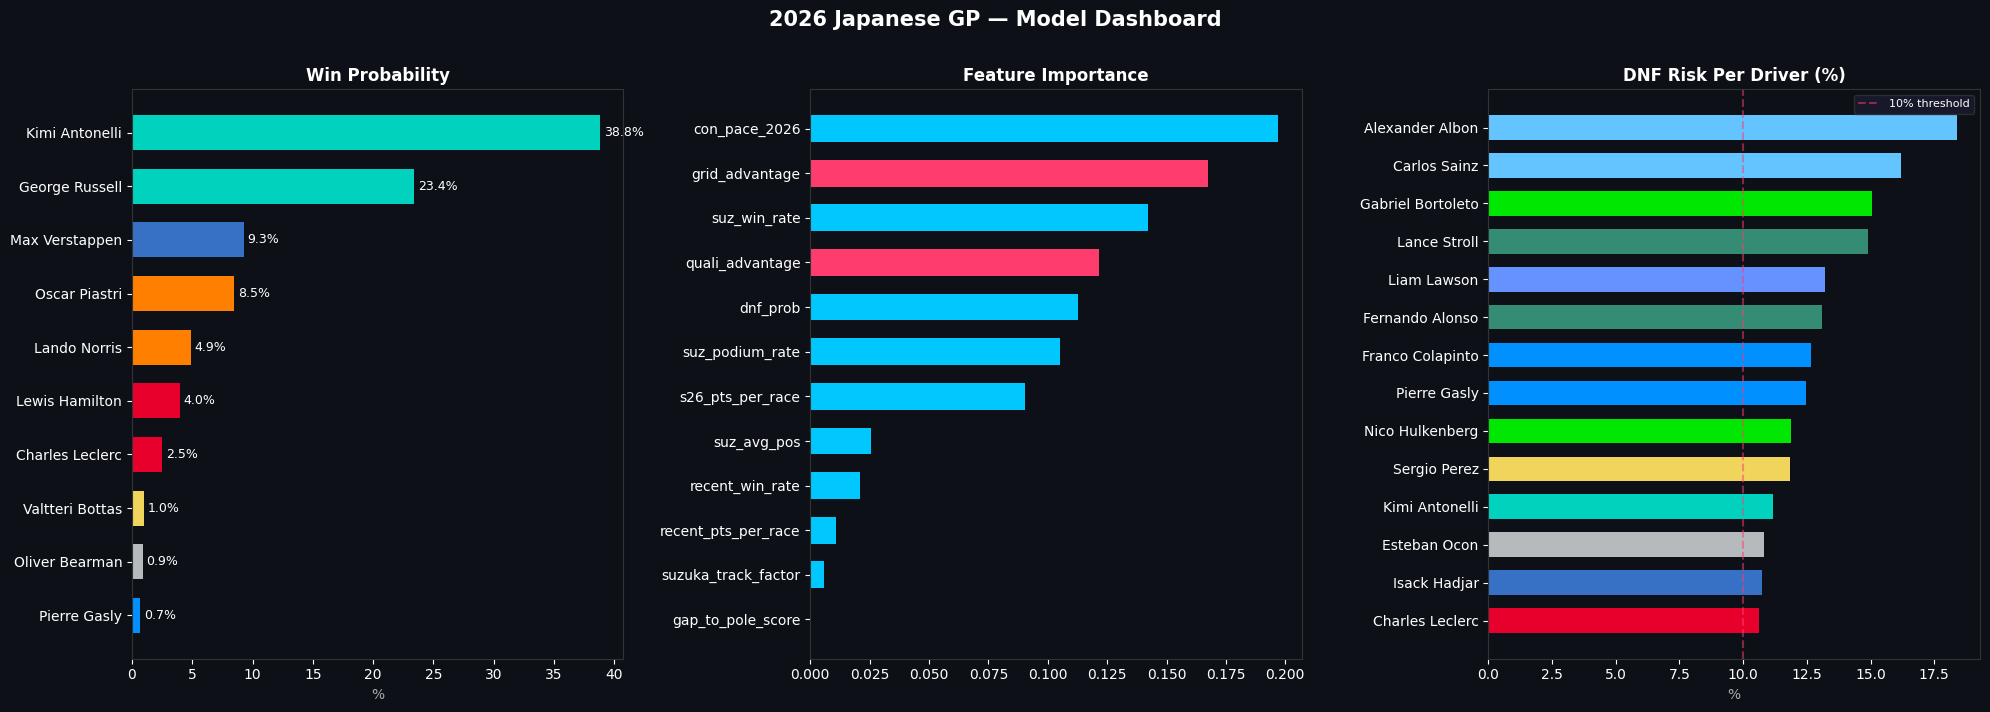

 Dashboard saved!


In [54]:

# CELL 14 — Visualisations
#  1. Win probability chart
#  2. Feature importance
#  3. DNF risk per driver
#

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.patch.set_facecolor('#0d1117')
fig.suptitle('2026 Japanese GP — Model Dashboard', color='white',
             fontsize=15, fontweight='bold', y=1.01)

#  Plot 1: Win probability
ax1 = axes[0]
ax1.set_facecolor('#0d1117')
top10  = final.head(10)
colors = [TEAM_COLORS.get(c,'#888') for c in top10['team']]
bars   = ax1.barh(top10['driver'][::-1], top10['final_pct'][::-1],
                  color=colors[::-1], edgecolor='none', height=0.65)
for bar, val in zip(bars, top10['final_pct'][::-1]):
    ax1.text(bar.get_width()+0.3, bar.get_y()+bar.get_height()/2,
             f'{val:.1f}%', va='center', ha='left', color='white', fontsize=9)
ax1.set_title('Win Probability', color='white', fontweight='bold')
ax1.tick_params(colors='white')
for sp in ax1.spines.values(): sp.set_color('#333')
ax1.set_xlabel('%', color='#aaa')

#  Plot 2: Feature importance
ax2 = axes[1]
ax2.set_facecolor('#0d1117')
feat_imp = pd.DataFrame({'feature': FEATURES,
                          'importance': best_model.feature_importances_})\
             .sort_values('importance', ascending=True).tail(12)
bcols = ['#ff3c6e' if any(k in f for k in ['grid','quali','gap']) else '#00c8ff'
         for f in feat_imp['feature']]
ax2.barh(feat_imp['feature'], feat_imp['importance'],
         color=bcols, edgecolor='none', height=0.6)
ax2.set_title('Feature Importance', color='white', fontweight='bold')
ax2.tick_params(colors='white')
for sp in ax2.spines.values(): sp.set_color('#333')

# ── Plot 3: DNF risk per driver ───────────────────
ax3 = axes[2]
ax3.set_facecolor('#0d1117')
dnf_plot = df[['driver_name','constructor','dnf_prob']]\
             .sort_values('dnf_prob', ascending=True).tail(14)
dcols = [TEAM_COLORS.get(c,'#888') for c in dnf_plot['constructor']]
ax3.barh(dnf_plot['driver_name'], dnf_plot['dnf_prob']*100,
         color=dcols, edgecolor='none', height=0.65)
ax3.axvline(x=10, color='#ff3c6e', linestyle='--', alpha=0.5, label='10% threshold')
ax3.set_title('DNF Risk Per Driver (%)', color='white', fontweight='bold')
ax3.tick_params(colors='white')
ax3.set_xlabel('%', color='#aaa')
ax3.legend(facecolor='#1a1a2e', edgecolor='#333', labelcolor='white', fontsize=8)
for sp in ax3.spines.values(): sp.set_color('#333')

plt.tight_layout()
plt.savefig('japanese_gp_2026_dashboard.png', dpi=150,
            bbox_inches='tight', facecolor='#0d1117')
plt.show()
print(' Dashboard saved!')